###  **Airbnb NYC Market Analysis — Pricing Drivers & Revenue Opportunities**

 **Project Overview**

 Analyzed 20,000+ Airbnb listings across New York City to identify pricing drivers, room-type demand patterns, host concentration, and availability trends. The project focuses on uncovering actionable insights that could help hosts optimize pricing strategies and understand competitive market dynamics.

 **Key Questions**

 1. Which NYC boroughs provide the highest revenue opportunity for Airbnb hosts?

2. Which room types maximize pricing efficiency and occupancy potential?

1. Which borough has the highest Airbnb prices?

2. How does room type affect pricing?

3. Do cheaper listings receive more reviews?

4. Which hosts dominate the market?

5. How does availability impact engagement?

6. Where are expensive listing concentrated geographically?

**Tools & Technologies**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

**Dataset Information**

- Source: NYC Airbnb Open Dataset
- Total Records: 20,000+ listings
- Features: Pricing, Room Type, Availability, Reviews, Host Data, Geographic Coordinates

#### **1. Setup & Environment**

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


print("Libraries Imported Successful")

Libraries Imported Successful


#### **2. Data Loading**

In [65]:
df = pd.read_csv('../data/new_york_airbnb_2024.csv', encoding_errors='ignore')

print("Dataset Loaded Successfully")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head())

Dataset Loaded Successfully
Rows: 20,770
Columns: 22


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1.312228e+06,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,20/12/15,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified
1,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01/05/23,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
2,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18/12/23,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
3,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17/09/23,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
4,4.089661e+07,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,03/12/23,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1


#### **3. Initial Data Inspection**


This section evaluates the structure, quality, and completeness of the dataset before performing cleaning and analysis.

The objective is to identify:
- dataset dimensions
- column datatypes
- missing values
- duplicate records
- potential inconsistencies
- overall data reliability

In [66]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1.312228e+06,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,20/12/15,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified
1,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01/05/23,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
2,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18/12/23,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
3,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17/09/23,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
4,4.089661e+07,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,03/12/23,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1


In [67]:
print("="*20)
print("DATASET OVERVIEW")
print("="*20)

print(f"Total Rows    : {df.shape[0]:,}")
print(f"Total Columns : {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

DATASET OVERVIEW
Total Rows    : 20,770
Total Columns : 22

Column Names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license', 'rating', 'bedrooms', 'beds', 'baths']


In [68]:
print("="*10)
print("DATA TYPES")
print("="*10)

display(df.dtypes)

DATA TYPES


id                                float64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                               str
rating                                str
bedrooms                              str
beds                                int64
baths                                 str
dtype: object

In [69]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values = missing_values[missing_values > 0]

display(missing_values)

price                             34
neighbourhood                      7
room_type                          7
longitude                          7
latitude                           7
minimum_nights                     7
calculated_host_listings_count     7
availability_365                   7
number_of_reviews_ltm              7
reviews_per_month                  7
last_review                        7
number_of_reviews                  7
dtype: int64

**Observation**
 
 - 7 rows have missing values across multiple columns like - availability, room type, minimum nights etc.
 - 34 rows have missing values in price, will drop during cleaning.
 - baths, bedrooms, rating are stored as str(text) instead of numbers - needs fixing.
 - id and host_id are stored as numbers but they are identifiers, should convert them to object.

#### **4. Data Cleaning & Preparation**

This section focuses on improving dataset quality before analysis.

The cleaning process includes:
- handling missing values
- removing duplicate records
- validating numerical fields
- correcting inconsistent values
- preparing features for analysis

The objective is to ensure analytical accuracy and reliability.

#### **Handling Missing Values** 

In [70]:
df.isnull().sum().sum()

np.int64(111)

In [71]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_data = pd.DataFrame({
    'Column Name':missing_values.index,
    'Missing Values':missing_values.values,
    'Percentage': missing_percentage.values
})

display(missing_data[missing_data['Missing Values'] > 0])
                                                    

,Column Name,Missing Values,Percentage
5,neighbourhood,7,0.03
6,latitude,7,0.03
7,longitude,7,0.03
8,room_type,7,0.03
9,price,34,0.16
10,minimum_nights,7,0.03
11,number_of_reviews,7,0.03
12,last_review,7,0.03
13,reviews_per_month,7,0.03
14,calculated_host_listings_count,7,0.03


**Missing Value Observation**

- The dataset contains very few missing values across all columns.
- The highest number of missing values is 34 which is in 'price' column, and the missing percentage is 0.16% while most other columns contain just 0.03% missing values.
- Since the missing data affect less than 1% of the dataset, removing these rows won't affect the overall analysis.

In [72]:
print(f"Rows before dropping null values: {df.shape[0]:,}")

df=df.dropna()

print(f"Rows after dropping null values: {df.shape[0]:,}")

Rows before dropping null values: 20,770
Rows after dropping null values: 20,736


In [73]:
df.isnull().sum().sum()

np.int64(0)

#### **Duplicate handling**

In [74]:
duplicate_count = df.duplicated().sum()

print(f"Number Of Duplicate Rows: {duplicate_count}")

Number Of Duplicate Rows: 12


**Duplicate Observation**

- The dataset contains 12 duplicate rows out of 20736 listing.
- These duplicate records can distort the analysis by inflating counts and affect statistical calculations
- They will be removed before further analysis to ensure accurate and reliable analysis

In [75]:
duplicate_ids = df[df.duplicated(subset=['id'], keep=False)]
duplicate_ids.sort_values('id')


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
20742,3.339399e+06,Rental unit in New York · ★4.73 · 1 bedroom · ...,2119276,Urban Furnished,Manhattan,West Village,40.732030,-74.006760,Entire home/apt,143.0,...,09/05/23,0.20,54.0,285.0,2.0,No License,4.73,1,1,1
20735,3.339399e+06,Rental unit in New York · ★4.73 · 1 bedroom · ...,2119276,Urban Furnished,Manhattan,West Village,40.732030,-74.006760,Entire home/apt,143.0,...,09/05/23,0.20,54.0,285.0,2.0,No License,4.73,1,1,1
3,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17/09/23,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
8,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17/09/23,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
20732,1.336161e+07,Rental unit in New York · ★4.89 · 2 bedrooms ·...,8961407,Jamie,Manhattan,Harlem,40.805700,-73.946250,Entire home/apt,397.0,...,08/09/23,1.08,3.0,274.0,3.0,No License,4.89,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,1.050000e+18,Rental unit in New York · ★5.0 · 1 bedroom · 1...,538591650,LuxuryStaysNYC,Manhattan,Hell's Kitchen,40.762580,-74.001210,Entire home/apt,290.0,...,01/01/24,3.00,4.0,243.0,3.0,OSE-STRREG-0001306,5,1,1,1
1890,1.050000e+18,Rental unit in New York · ★New · 1 bedroom · 2...,516081263,Ceejay,Manhattan,East Village,40.728059,-73.983870,Entire home/apt,150.0,...,01/01/24,1.00,1.0,4.0,1.0,OSE-STRREG-1079106,New,1,2,1
13331,1.050000e+18,Aparthotel in New York · ★New · 2 bedrooms · 3...,471177409,Blair,Manhattan,East Village,40.723048,-73.987767,Entire home/apt,357.0,...,01/01/24,1.00,1.0,253.0,1.0,Exempt,New,2,3,1.5
18646,1.050000e+18,Rental unit in New York · ★New · 1 bedroom · 2...,522477903,Art Ryan,Manhattan,Kips Bay,40.742200,-73.976880,Entire home/apt,155.0,...,31/12/23,1.00,1.0,279.0,1.0,OSE-STRREG-1081622,New,1,2,1


In [76]:
df[df.duplicated()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
6,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01/05/23,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
7,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18/12/23,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
8,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17/09/23,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
9,4.089661e+07,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,03/12/23,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1
10,4.958498e+07,Rental unit in New York · ★5.0 · 1 bedroom · 1...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.759950,-73.992960,Entire home/apt,115.0,...,29/07/23,0.16,139.0,276.0,2.0,No License,5,1,1,1
20736,7.990000e+17,Rental unit in New York · 2 bedrooms · 2 beds ...,224733902,CozySuites Copake,Manhattan,Upper East Side,40.768970,-73.957592,Entire home/apt,153.0,...,15/09/23,0.41,8.0,308.0,2.0,No License,No rating,2,2,2
20737,5.930000e+17,Rental unit in New York · ★4.79 · 2 bedrooms ·...,23219783,Rob,Manhattan,West Village,40.730220,-74.002910,Entire home/apt,175.0,...,22/11/23,2.03,4.0,129.0,25.0,No License,4.79,2,2,1
20738,9.230000e+17,Loft in New York · ★4.33 · 1 bedroom · 2 beds ...,520265731,Rodrigo,Manhattan,Greenwich Village,40.728390,-73.999540,Entire home/apt,156.0,...,02/01/24,2.60,1.0,356.0,9.0,Exempt,4.33,1,2,1
20739,1.336161e+07,Rental unit in New York · ★4.89 · 2 bedrooms ·...,8961407,Jamie,Manhattan,Harlem,40.805700,-73.946250,Entire home/apt,397.0,...,08/09/23,1.08,3.0,274.0,3.0,No License,4.89,2,2,1
20740,5.119566e+07,Rental unit in New York · Studio · 1 bed · 1 bath,51501835,Jeniffer,Manhattan,Chinatown,40.718360,-73.995850,Entire home/apt,100.0,...,25/05/23,0.08,139.0,306.0,1.0,No License,No rating,Studio,1,1


**Observation**

- These are the duplicate rows 

In [77]:
print(f"Rows Before Removing Duplicates: {df.shape[0]:,}")

df.drop_duplicates(inplace=True)

print(f"Rows After Removing Duplicates: {df.shape[0]:,}")

df.duplicated().sum()

Rows Before Removing Duplicates: 20,736
Rows After Removing Duplicates: 20,724


np.int64(0)

#### **Datatype Inspection**

In [78]:
df.dtypes

id                                float64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                               str
rating                                str
bedrooms                              str
beds                                int64
baths                                 str
dtype: object

In [79]:
print(df['rating'].unique())

<StringArray>
[        '5',      '4.67',      '4.17',      '4.64',      '4.91',      '4.33',
       '4.5',      '4.79', 'No rating',      '4.71',
 ...
      '2.89',      '3.55',      '3.85',      '1.75',      '3.58',      '3.22',
      '3.77',      '3.65',      '3.87',      '2.75']
Length: 162, dtype: str


In [80]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

print(df['rating'].dtype)

float64


In [81]:
print(df['bedrooms'].unique())

<StringArray>
['1', '2', 'Studio', '3', '6', '5', '4', '7', '15', '9', '8', '14']
Length: 12, dtype: str


In [82]:
df['bedrooms'] = df['bedrooms'].replace('Studio', '0')

df['bedrooms'] = pd.to_numeric(df['bedrooms'])

print(df['bedrooms'].dtype)

df.dtypes

int64


id                                float64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                               str
rating                            float64
bedrooms                            int64
beds                                int64
baths                                 str
dtype: object

In [83]:
print(df['baths'].unique())

<StringArray>
['Not specified',             '1',             '2',           '1.5',
             '3',             '4',           '3.5',             '0',
           '2.5',             '5',           '4.5',             '6',
           '5.5',          '11.5',           '6.5',          '15.5']
Length: 16, dtype: str


In [84]:
df['baths'] = df['baths'].replace('Not specified', '0')

df['baths'] = pd.to_numeric(df['baths'])

print(df['baths'].dtype)

df.dtypes

float64


id                                float64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                               str
rating                            float64
bedrooms                            int64
beds                                int64
baths                             float64
dtype: object

In [85]:
print(df['last_review'].unique())

<StringArray>
['20/12/15', '01/05/23', '18/12/23', '17/09/23', '03/12/23', '29/07/23',
 '31/08/22', '30/05/23', '01/10/23', '19/10/23',
 ...
 '05/11/20', '21/05/19', '24/06/19', '21/08/15', '16/10/19', '29/05/15',
 '24/06/16', '13/12/15', '15/03/18', '11/07/19']
Length: 1876, dtype: str


In [86]:
df['last_review'] = pd.to_datetime(df['last_review'], dayfirst=True)

print(df['last_review'].dtype)

df['last_review'].head()

df.dtypes

datetime64[us]


id                                       float64
name                                         str
host_id                                    int64
host_name                                    str
neighbourhood_group                          str
neighbourhood                                str
latitude                                 float64
longitude                                float64
room_type                                    str
price                                    float64
minimum_nights                           float64
number_of_reviews                        float64
last_review                       datetime64[us]
reviews_per_month                        float64
calculated_host_listings_count           float64
availability_365                         float64
number_of_reviews_ltm                    float64
license                                      str
rating                                   float64
bedrooms                                   int64
beds                

**Datatype Conversion**

During datatype inspection, several columns were found to have incorrect datatypes due to mixed or non-numeric values in the dataset.

Datatype conversions were performed in the following columns:

- 'rating' was converted from 'str' to 'float64' using errors=coerce, which automatically converts non-numeric values into 'NaN'

- 'bedrooms' was converted from 'str' to 'int64'
replacing 'studio' with '0' to represent studio apartment without separate bedrooms.

- 'baths' was converted from 'str' to 'float64'
replacing 'Not specified' with '0', to enable numerical analysis.

- 'last_review' was converted from 'str' to 'datetime' using pd.to_datetime() with 'dayfirst=True' because the dates were stored in day/month/year format.


In [87]:
df.to_csv(
    '../outputs/cleaned_airbnb_data.csv',
    index=False
)

### **5. Exploratory Analysis**
**Outlier Detection & Handling**

Outlier Detection & Handling

- Outliers are extreme values that differ from the majority of the dataset.

- In airbnb listing, 'price' column contains luxury listing with extremely high prices. These values can distort statistical analysis and visualization.

- Therefore, outlier detection is necessary before performing exploratory data analysis.

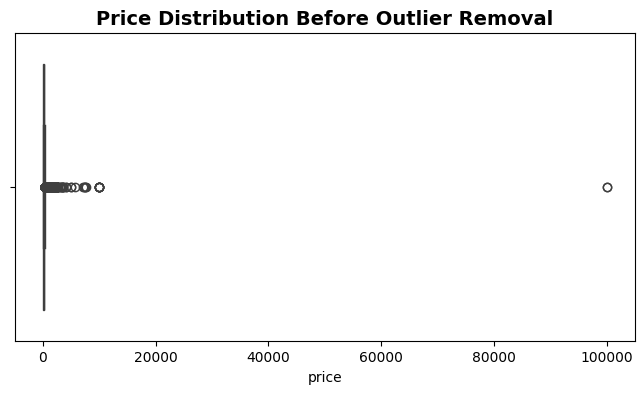

In [88]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['price'])

plt.title('Price Distribution Before Outlier Removal',
          fontsize=14,
          fontweight='bold')

plt.xlabel('price')

plt.savefig(
    '../images/Price Distribution Before Outlier Removal.png',
    bbox_inches='tight'
)

plt.show()


**IOR Method**

In [89]:
Q1 = df['price'].quantile(0.25)

Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

upper_fence = Q3 +(1.5 * IQR)

print(f"Q1: {Q1}")

print(f"Q3: {Q3}")

print(f"IQR: {IQR}")

print(f"Upper Fence: {upper_fence}")

Q1: 80.0
Q3: 199.0
IQR: 119.0
Upper Fence: 377.5


**IQR Observation**

- The IQR method was used to identify extreme values in the price distribution.

- The IQR method identified prices above $377.5 as potential outliers.

- Listings priced far above the upper_fence is considered as potential outliers because they differ far from the majority of listings and may distort statistical analysis.


In [90]:
print(f"Listings above $377.5: {(df['price'] >= 377.5).sum()}")

print(f"Listings above $3000: {(df['price'] >= 3000).sum()}")

Listings above $377.5: 1382
Listings above $3000: 27


- Prices above $377.5 is considered as outliers, identified by IQR method.

- But removing these outliers can end up in removing many realistic properties, as this dataset contains premium and luxury listings.

- Therefore, a practical cutoff of $3000 was chosen so it remove only extreme luxury listing while preseving majority of genuine luxury listing.

In [91]:
print(f"Rows Before Outlier Removal: {df.shape[0]:,}")

df = df[df['price'] < 3000]

print(f"Rows After Outlier Removal: {df.shape[0]:,}")

Rows Before Outlier Removal: 20,724
Rows After Outlier Removal: 20,697


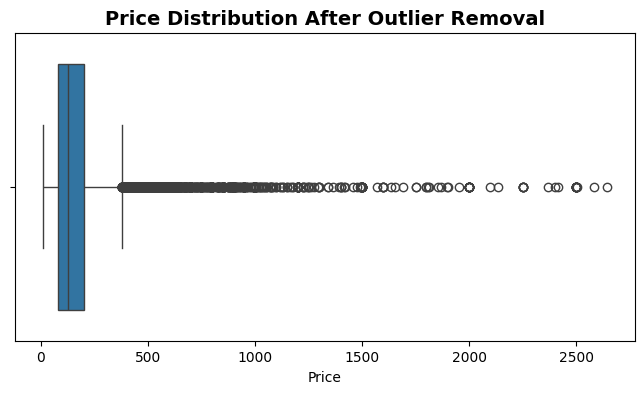

In [92]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['price'])

plt.title('Price Distribution After Outlier Removal',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Price')

plt.savefig(
    '../images/Price Distribution After Outlier Removal.png',
    bbox_inches='tight'
)

plt.show()

In [93]:
df['price'].describe()

count    20697.000000
mean       170.723148
std        178.755640
min         10.000000
25%         80.000000
50%        125.000000
75%        199.000000
max       2643.000000
Name: price, dtype: float64

**Cleaning Observation**

- After removing extreme listing above $3000, the price distribution became more balanced and easier to analyze.

- The dataset still contains some high-priced listings, but it represents realistic permium airbnb properties.

**EXPLORATORY DATA ANALYSIS**

**Univariate Analysis**

It focuses on analyzing one variable at a time to understand its distribution, spread, and overall patterns within the dataset.

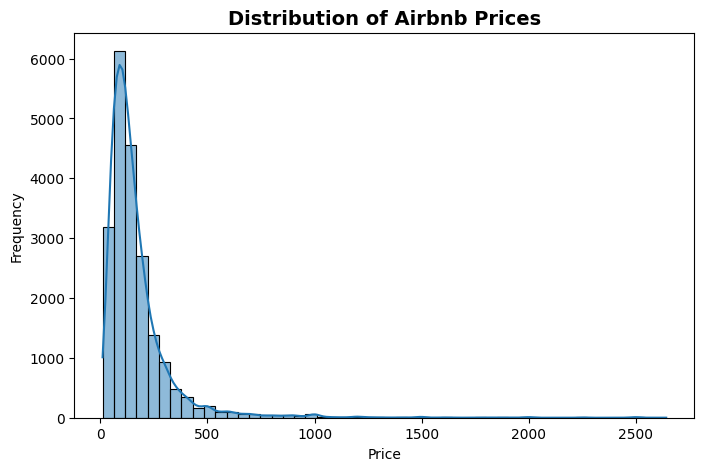

In [94]:
plt.figure(figsize=(8, 5))

sns.histplot(df['price'], bins=50, kde=True)

plt.title('Distribution of Airbnb Prices',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Price')

plt.ylabel('Frequency')

plt.savefig(
    '../images/Distribution of Airbnb Prices.png',
    bbox_inches='tight'
)

plt.show()



**Price Distribution Observation**

- The majority of Airbnb listings are concentrated in the lower price range, with most properties priced below $300.

- The distribution is positively skewed (right-skewed), as a small number of high-priced listings extend the tail toward the right side.

- The frequency of listings decreases as price increases, indicating that affordable and mid-range properties dominate the market.

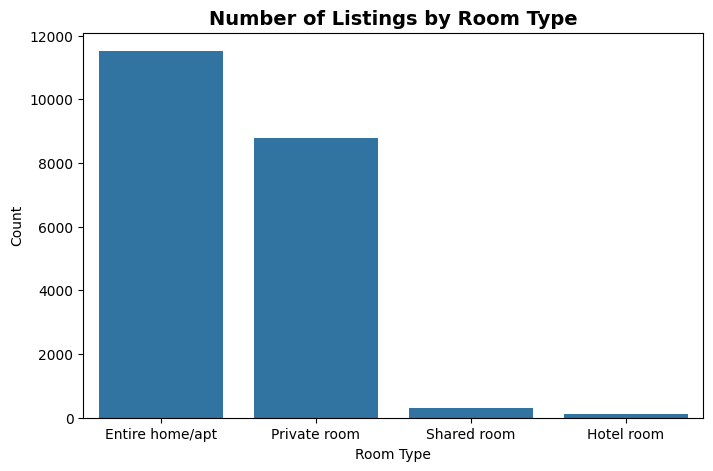

In [95]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='room_type',
    order=df['room_type'].value_counts().index
)

plt.title('Number of Listings by Room Type',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Room Type')

plt.ylabel('Count')

plt.savefig(
    '../images/Number of Listings by Room Type.png',
    bbox_inches='tight'
)

plt.show()

**Room Type Distribution Observation**

- Entire home/apartment listings dominate the Airbnb market, followed by private rooms.

- Shared rooms and hotel rooms represent only a very small proportion of total listings.

- This suggests that most guests prefer private accommodation options rather than shared living spaces.

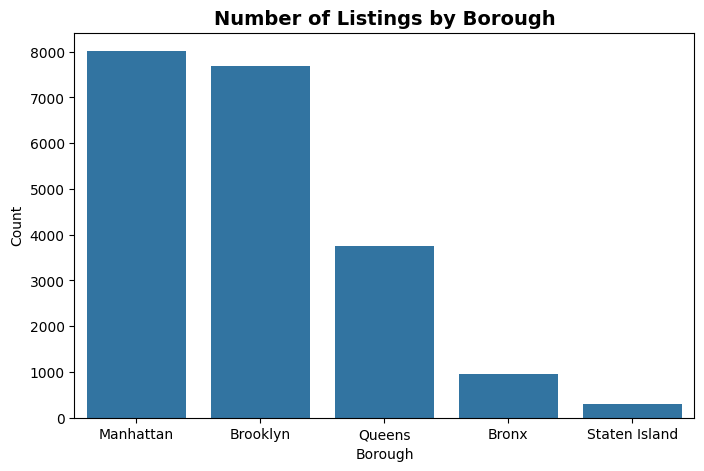

In [96]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='neighbourhood_group',
    order=df['neighbourhood_group'].value_counts().index
)

plt.title('Number of Listings by Borough',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Borough')

plt.ylabel('Count')

plt.savefig(
    '../images/Number of Listings by Borough.png',
    bbox_inches='tight'
)

plt.show()

**Borough Distribution Observation**

- Manhattan contains the highest number of Airbnb listings, closely followed by Brooklyn.

- Queens has a moderate number of listings, while Bronx and Staten Island contribute only a small share of the market.

- This indicates that Airbnb activity is heavily concentrated in Manhattan and Brooklyn, likely due to higher tourism demand, accessibility, and urban activity.

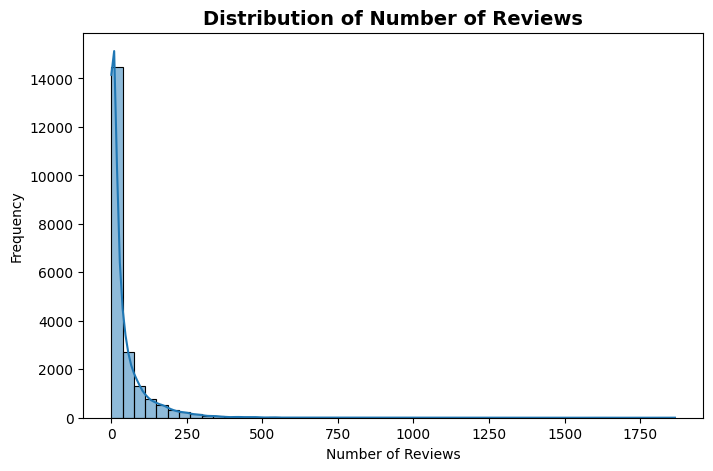

In [97]:
plt.figure(figsize=(8, 5))

sns.histplot(df['number_of_reviews'], bins=50, kde=True)

plt.title('Distribution of Number of Reviews',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Number of Reviews')

plt.ylabel('Frequency')

plt.savefig(
    '../images/Distribution of Number of Reviews.png',
    bbox_inches='tight'
)

plt.show()

**Review Distribution Observation**

- Most Airbnb listings have relatively low review counts, while only a small number of listings receive extremely high numbers of reviews.

- The distribution is heavily right-skewed, indicating that guest engagement is concentrated among a limited number of highly active listings.

- The frequency decreases rapidly as the number of reviews increases, suggesting that only a few properties dominate booking activity and customer interactions.

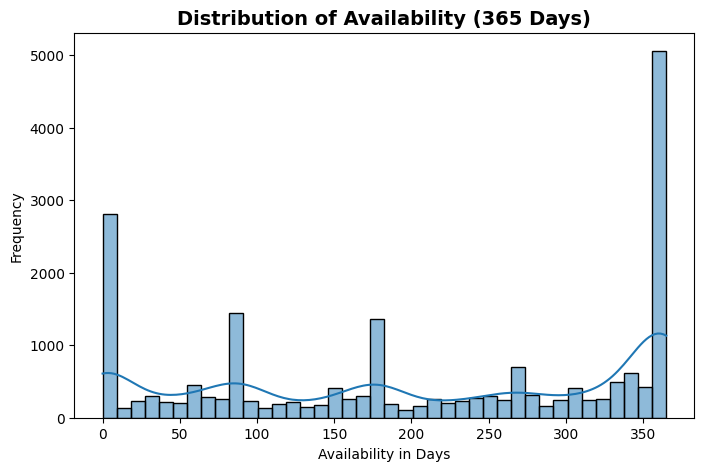

In [98]:
plt.figure(figsize=(8, 5))

sns.histplot(df['availability_365'], bins=40, kde=True)

plt.title('Distribution of Availability (365 Days)',
         fontsize=14,
         fontweight='bold' )

plt.xlabel('Availability in Days')

plt.ylabel('Frequency')

plt.savefig(
    '../images/Distribution of Availability (365 Days).png',
    bbox_inches='tight'
)

plt.show()

**Availability Distribution Observation**

- A large number of Airbnb listings are available for most of the year, particularly around 365 days.

- Another noticeable group of listings has very low availability, indicating that some properties may either be frequently booked or only occasionally listed.

- The distribution contains several spikes across different availability ranges, suggesting varying hosting strategies and seasonal availability patterns among hosts.

**Bivariate Analysis**

Bivariate analysis examines the relationship between two variables to identify patterns, trends, and possible correlations within the dataset.

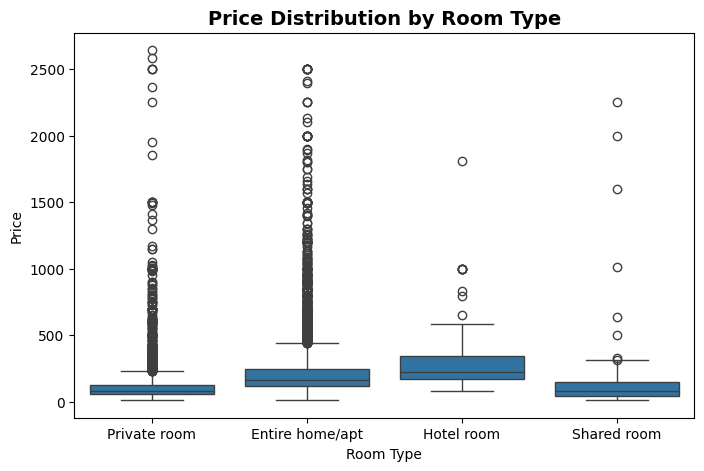

In [99]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='room_type',
    y='price'
)

plt.title('Price Distribution by Room Type',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Room Type')

plt.ylabel('Price')

plt.savefig(
    '../images/Price Distribution by Room Type.png',
    bbox_inches='tight'
)

plt.show()

**Price vs Room Type Observation**

- Hotel rooms have the highest median prices among all room types, indicating that they are generally the most expensive accommodation option.

- Entire home/apartment listings also show relatively high prices and large variability, reflecting differences in property size, location, and amenities.

- Private rooms and shared rooms are comparatively more affordable, with shared rooms showing the lowest overall pricing.

- A large number of outliers exist across all room types, suggesting the presence of premium and luxury listings within each category.

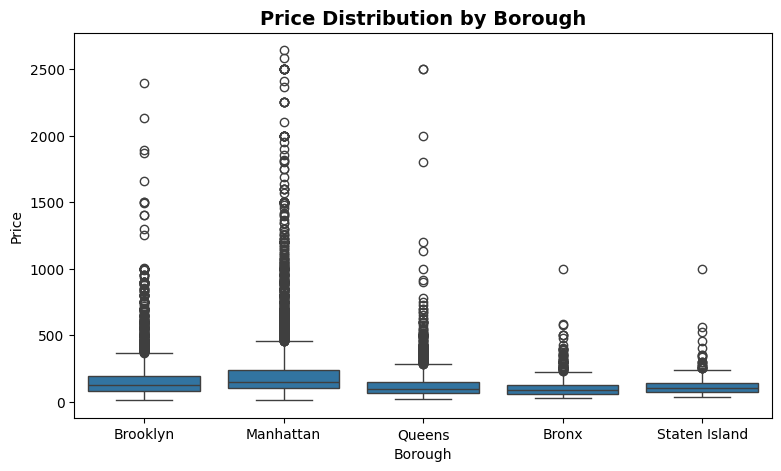

In [100]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='neighbourhood_group',
    y='price'
)

plt.title('Price Distribution by Borough',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Borough')

plt.ylabel('Price')

plt.savefig(
    '../images/Price Distribution by Borough.png',
    bbox_inches='tight'
)

plt.show()

**Price Distribution by Borough Observation**

- Manhattan has the highest median price among all boroughs, indicating that it is generally the most expensive Airbnb market in New York.

- Brooklyn also shows relatively high pricing, while Queens, Bronx, and Staten Island have lower median prices.

- Manhattan displays the largest spread and highest number of outliers, suggesting a wide variation in property pricing and the presence of many premium and luxury listings.

- The boroughs with lower median prices also show comparatively smaller price variability.

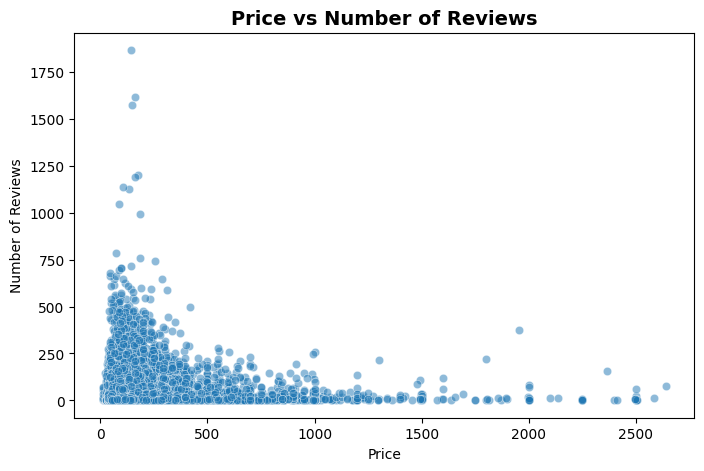

In [101]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='price',
    y='number_of_reviews',
    alpha=0.5
)

plt.title('Price vs Number of Reviews',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Price')

plt.ylabel('Number of Reviews')

plt.savefig(
    '../images/Price vs Number of Reviews.png',
    bbox_inches='tight'
)

plt.show()

**Price vs Number of Reviews Observation**

- Most Airbnb listings are concentrated in the lower price range with relatively fewer reviews overall.

- Listings with lower and moderate prices tend to receive higher numbers of reviews, suggesting greater customer engagement and booking activity.

- As price increases, the number of reviews generally decreases, indicating a weak negative relationship between pricing and review activity.


**Correlation Analysis**

In [102]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,rating,bedrooms,beds,baths
id,1.000000,0.422759,0.009326,0.068061,0.041302,-0.073725,-0.283019,0.138021,-0.010767,0.101314,0.037389,0.000104,0.084190,0.041291,0.043408
host_id,0.422759,1.000000,0.011688,0.122697,-0.012530,-0.072511,-0.139676,0.170606,-0.050246,0.082490,0.100901,-0.115659,0.051805,0.057085,0.009678
latitude,0.009326,0.011688,1.000000,0.046434,0.018661,0.004274,-0.048056,-0.041865,0.069921,-0.005222,-0.041818,-0.073194,-0.093933,-0.070535,-0.035285
longitude,0.068061,0.122697,0.046434,1.000000,-0.171596,0.024124,0.005449,0.042222,-0.072497,0.062138,0.033413,0.004560,0.071213,0.036690,-0.009607
price,0.041302,-0.012530,0.018661,-0.171596,1.000000,-0.042084,-0.042221,-0.020164,-0.019779,0.049873,-0.036385,0.089655,0.379728,0.391874,0.363472
minimum_nights,-0.073725,-0.072511,0.004274,0.024124,-0.042084,1.000000,-0.059016,-0.122434,0.015059,0.034789,-0.092394,-0.010070,-0.007459,-0.026251,0.007922
number_of_reviews,-0.283019,-0.139676,-0.048056,0.005449,-0.042221,-0.059016,1.000000,0.631514,-0.114739,-0.050070,0.605885,0.066226,-0.018556,0.036026,-0.055036
reviews_per_month,0.138021,0.170606,-0.041865,0.042222,-0.020164,-0.122434,0.631514,1.000000,-0.108768,-0.040565,0.849735,0.057510,0.011285,0.048402,-0.026679
calculated_host_listings_count,-0.010767,-0.050246,0.069921,-0.072497,-0.019779,0.015059,-0.114739,-0.108768,1.000000,0.046618,-0.091787,-0.149260,-0.049841,-0.070843,-0.006726
availability_365,0.101314,0.082490,-0.005222,0.062138,0.049873,0.034789,-0.050070,-0.040565,0.046618,1.000000,-0.049124,-0.054350,0.065114,0.065374,0.050136


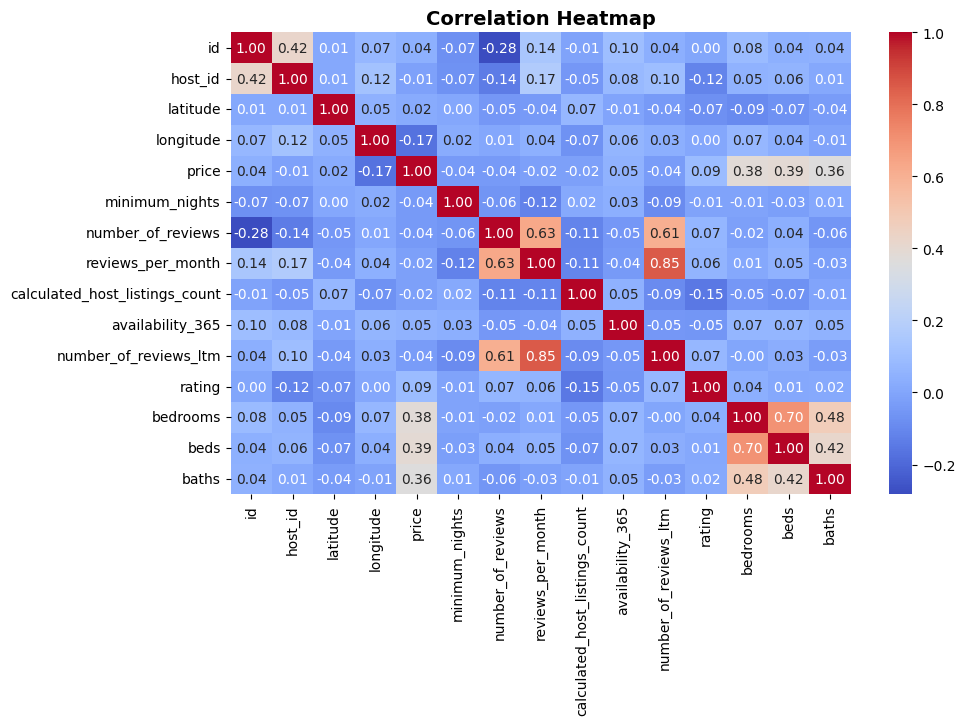

In [103]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap',
          fontsize=14,
          fontweight='bold')

plt.savefig(
    '../images/Correlation Heatmap.png',
    bbox_inches='tight'
)

plt.show()

**Correlation Analysis Observation**

- The strongest positive correlation is observed between 'reviews_per_month' and 'number_of_reviews_ltm' (0.85), indicating that listings receiving recent reviews also tend to maintain high monthly review activity.

- 'number_of_reviews' and 'reviews_per_month' also show a strong positive relationship, suggesting consistent customer engagement over time.

- 'bedrooms' and 'beds' exhibit a strong positive correlation, which is expected since larger properties generally accommodate more beds.

- Price shows weak-to-moderate positive correlations with 'bedrooms', 'beds', and 'baths', indicating that larger properties tend to be more expensive.

- Most other correlations are relatively weak, suggesting that Airbnb pricing and customer behavior are influenced by multiple interacting factors rather than a single variable.

#### **Advanced Exploratory Data Analysis**

This section focuses on deeper business insights using aggregation, grouping, and feature-based analysis to better understand Airbnb pricing, host activity, and customer behavior.

**Average Price By Room Type**

In [104]:
avg_price_room = (
    df.groupby('room_type')['price']
    .mean()
    .sort_values(ascending=False)
)

avg_price_room

room_type
Hotel room         302.609091
Entire home/apt    216.465347
Shared room        122.737931
Private room       110.690425
Name: price, dtype: float64

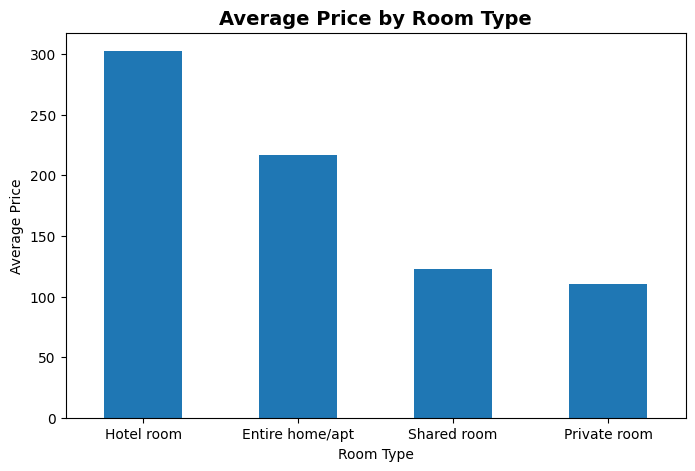

In [105]:
plt.figure(figsize=(8, 5))

avg_price_room.plot(kind='bar')

plt.title('Average Price by Room Type',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Room Type')

plt.ylabel('Average Price')

plt.xticks(rotation=0)

plt.savefig(
    '../images/Average Price by Room Type.png',
    bbox_inches='tight'
)

plt.show()

**TOP 10 MOST EXPENSIVE NEIGHBOURBOODS**

In [106]:
top_neighbourhoods = (
    df.groupby('neighbourhood')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_neighbourhoods

neighbourhood
Civic Center         393.750000
Tribeca              390.485714
SoHo                 363.507353
NoHo                 351.333333
Flatiron District    332.615385
DUMBO                312.882353
Greenwich Village    307.095238
West Village         306.673077
Neponsit             295.000000
Tottenville          269.000000
Name: price, dtype: float64

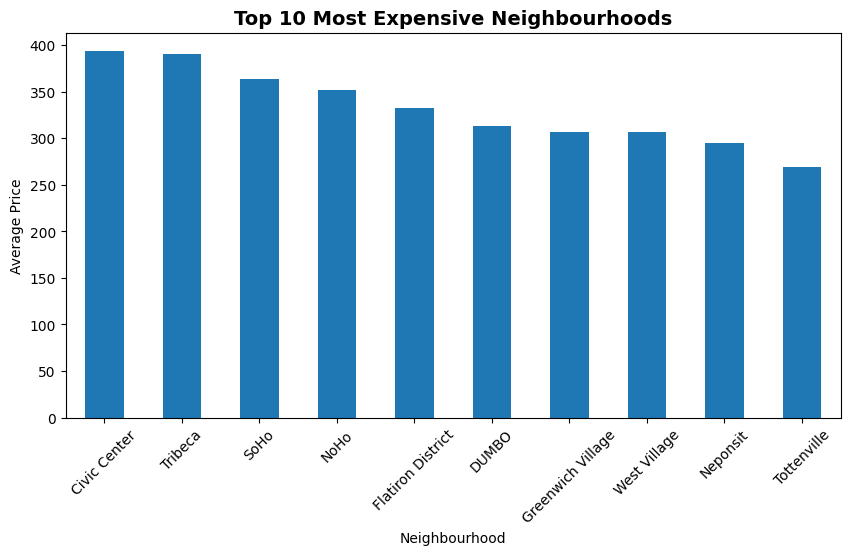

In [107]:
plt.figure(figsize=(10, 5))

top_neighbourhoods.plot(kind='bar')

plt.title('Top 10 Most Expensive Neighbourhoods',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Neighbourhood')

plt.ylabel('Average Price')

plt.xticks(rotation=45)

plt.savefig(
    '../images/Top 10 Most Expensive Neighbourhoods.png',
    bbox_inches='tight'
)

plt.show()

**Top Neighbourhood Observation**

- Several neighbourhoods show significantly higher average Airbnb prices compared to others.

- Premium neighbourhoods are likely influenced by factors such as tourism demand, luxury properties, accessibility, and central locations.

- This analysis highlights strong location-based pricing differences across New York City.

**CHEAPEST BOROUGHS**

In [108]:
avg_price_borough = (
    df.groupby('neighbourhood_group')['price']
    .mean()
    .sort_values()
)

avg_price_borough

neighbourhood_group
Bronx            107.990506
Staten Island    118.780069
Queens           123.894093
Brooklyn         156.683019
Manhattan        215.447785
Name: price, dtype: float64

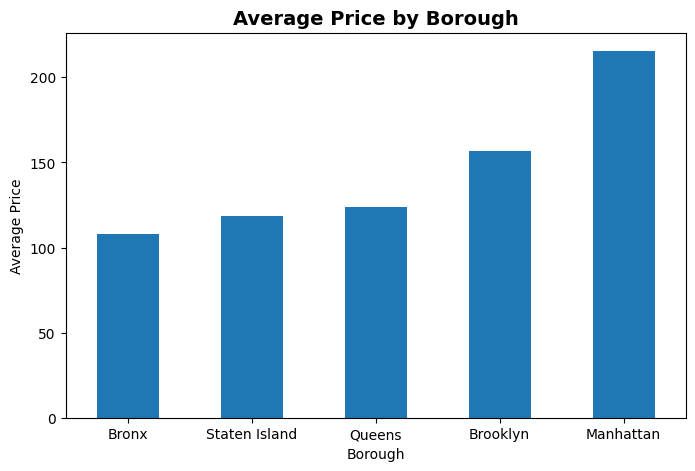

In [109]:
plt.figure(figsize=(8,5))

avg_price_borough.plot(kind='bar')

plt.title('Average Price by Borough',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Borough')

plt.ylabel('Average Price')

plt.xticks(rotation=0)

plt.savefig(
    '../images/Average Price by Borough.png',
    bbox_inches='tight'
)

plt.show()

In [110]:
borough_price = (
    df.groupby('neighbourhood_group')['price']
      .median()
      .sort_values(ascending=False)
)

borough_price.to_csv(
    '../outputs/borough_price_summary.csv'
)

**Borough Price Observation**

- Manhattan has the highest average Airbnb prices among all boroughs.

- Brooklyn also maintains relatively high pricing compared to other boroughs.

- Bronx and Staten Island appear to be the most affordable boroughs.

- The results indicate strong geographical influence on Airbnb pricing patterns.

**TOP HOSTS ANALYSIS**

In [111]:
top_hosts = (
    df.groupby('host_name')['calculated_host_listings_count']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

top_hosts

host_name
Blueground            713.0
Eugene                589.0
June                  348.0
Hiroki                267.0
RoomPicks             259.0
Urban Furnished       256.0
Shogo                 249.0
Momoyo                236.0
Reservations          201.0
Furnished Quarters    164.0
Name: calculated_host_listings_count, dtype: float64

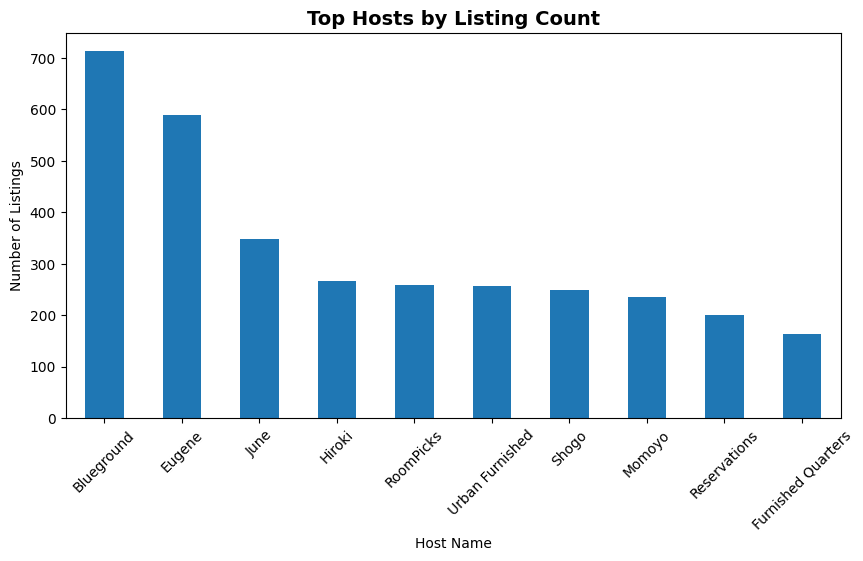

In [112]:
plt.figure(figsize=(10,5))

top_hosts.plot(kind='bar')

plt.title('Top Hosts by Listing Count',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Host Name')

plt.ylabel('Number of Listings')

plt.xticks(rotation=45)

plt.savefig(
    '../images/Top Hosts by Listing Count.png',
    bbox_inches='tight'
)

plt.show()

**Host Analysis Observation**

- A small number of hosts manage a significantly large number of listings.

- This suggests the presence of professional hosts or commercial property operators within the Airbnb market.

- Most hosts likely manage only a limited number of properties.

**TIME BASE-REVIEW ANALYSIS**

In [113]:
reviews_by_year = (
    df['last_review']
    .dt.year
    .value_counts()
    .sort_index()
)

reviews_by_year

last_review
2011        1
2012        6
2013       13
2014       19
2015       49
2016      102
2017      103
2018      227
2019      698
2020      826
2021      670
2022     1685
2023    15704
2024      594
Name: count, dtype: int64

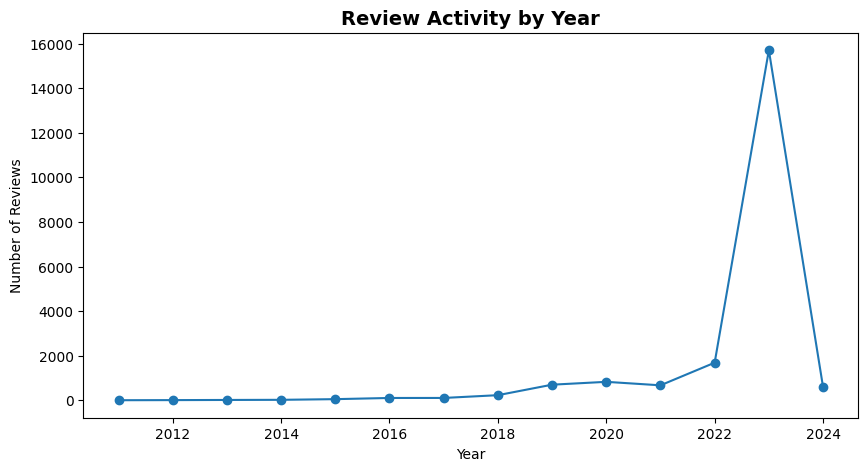

In [114]:
plt.figure(figsize=(10,5))

reviews_by_year.plot(kind='line', marker='o')

plt.title('Review Activity by Year',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Year')

plt.ylabel('Number of Reviews')

plt.savefig(
    '../images/Review Activity by Year.png',
    bbox_inches='tight'
)

plt.show()

**Review Trend Observation**

- Review activity varies across different years, reflecting changes in Airbnb usage and customer engagement over time.

- Certain years show significantly higher review counts, indicating periods of increased platform activity and travel demand.

**FEATURE ENGINEERING SECTION**

Feature engineering involves creating new variables from existing data to improve analysis and generate deeper business insights.

In [115]:
df['price_per_bedroom'] = df['price'] / (df['bedrooms'] + 1)

**Price Per Bedroom Feature**

This feature estimates pricing efficiency relative to property size by comparing listing price with number of bedrooms.

In [116]:
df['high_availability'] = df['availability_365'] > 300

**High Availability Feature**

This feature identifies listings available for most of the year, which may represent commercial or highly active rental properties.

In [117]:
df.to_csv(
    '../outputs/airbnb_feature_engineered.csv',
    index=False
)

### **Pricing Intelligence Analysis**

This section analyzes Airbnb pricing behavior across New York City to identify pricing distribution patterns, premium market segments, borough-level pricing differences, and room-type pricing behavior.

The objective is to understand how pricing varies across the NYC Airbnb ecosystem and identify potential market opportunities.

**PRICE DISTRIBUTION ANALYSIS**

In [118]:
price_df = df[df['price'] < 1000]

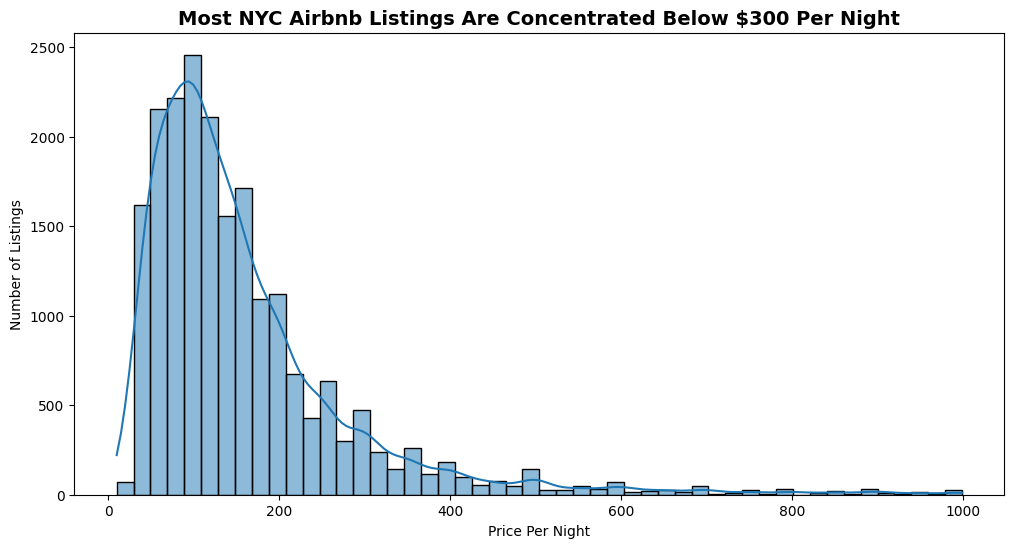

In [119]:
plt.figure(figsize=(12,6))

sns.histplot(
    price_df['price'],
    bins=50,
    kde=True
)

plt.title(
    "Most NYC Airbnb Listings Are Concentrated Below $300 Per Night",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Price Per Night")
plt.ylabel("Number of Listings")

plt.savefig(
    '../images/Most NYC Airbnb Listings Are Concentrated Below $300 Per Night.png',
    bbox_inches='tight'
)

plt.show()

**BOROUGH-LEVEL PRICING ANALYSIS**

In [120]:
borough_price = (
    df.groupby('neighbourhood_group')['price']
      .median()
      .sort_values(ascending=False)
)

display(borough_price)

neighbourhood_group
Manhattan        150.0
Brooklyn         125.0
Staten Island     99.0
Queens            98.0
Bronx             89.0
Name: price, dtype: float64

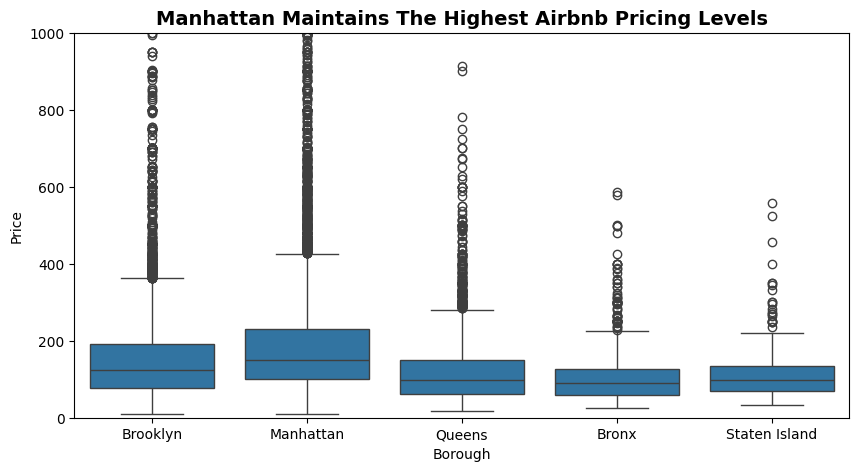

In [121]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=price_df,
    x='neighbourhood_group',
    y='price'
)

plt.title(
    "Manhattan Maintains The Highest Airbnb Pricing Levels",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Borough")
plt.ylabel("Price")

plt.ylim(0,1000)

plt.savefig(
    '../images/Manhattan Maintains The Highest Airbnb Pricing Levels.png',
    bbox_inches='tight'
)

plt.show()

**Insight**

Manhattan maintains the highest median Airbnb pricing levels, reinforcing its premium market positioning within NYC.

Brooklyn supports comparatively moderate pricing while still demonstrating strong market activity, suggesting balanced demand across mid-range segments.

**ROOM-TYPE PRICING ANALYSIS**

In [122]:
room_price = (
    df.groupby('room_type')['price']
      .median()
      .sort_values(ascending=False)
)

display(room_price)

room_type
Hotel room         221.5
Entire home/apt    160.0
Private room        80.0
Shared room         76.5
Name: price, dtype: float64

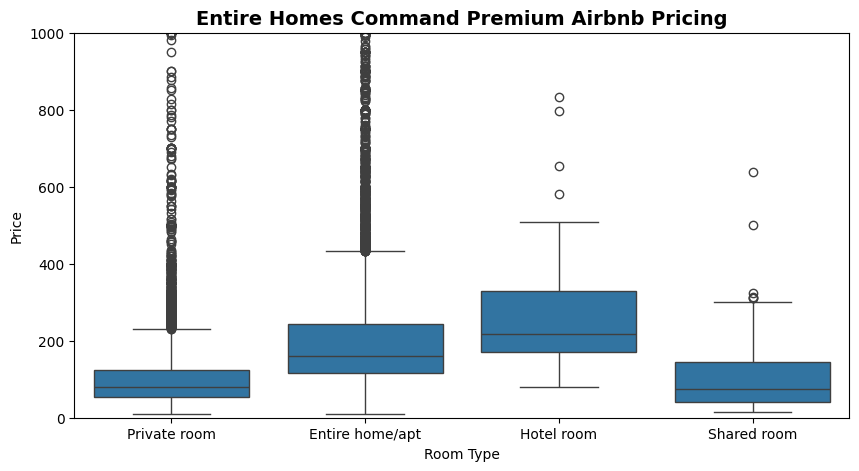

In [123]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=price_df,
    x='room_type',
    y='price'
)

plt.title(
    "Entire Homes Command Premium Airbnb Pricing",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Room Type")
plt.ylabel("Price")

plt.ylim(0,1000)

plt.savefig(
    '../images/Entire Homes Command Premium Airbnb Pricing.png',
    bbox_inches='tight'
)

plt.show()

**LUXURY MARKET SEGMENTATION**

In [124]:
df['price_category'] = pd.cut(
    df['price'],
    bins=[0,100,300,600,10000],
    labels=['Budget','Standard','Premium','Luxury']
)

In [125]:
price_segment = (
    df['price_category']
      .value_counts()
)

display(price_segment)

price_category
Standard    10599
Budget       7988
Premium      1614
Luxury        496
Name: count, dtype: int64

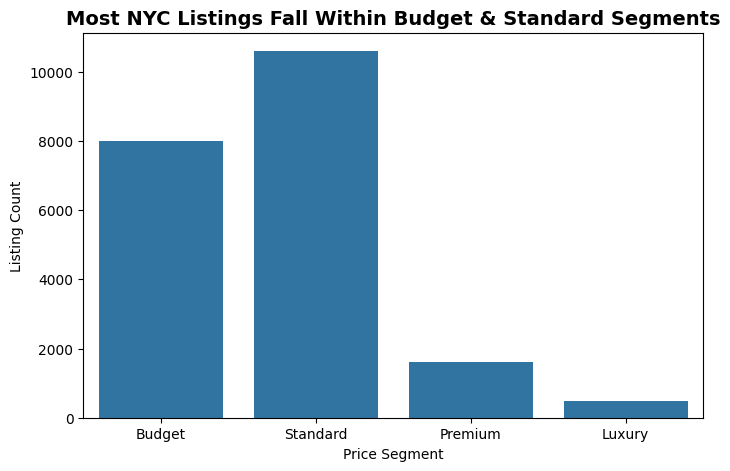

In [126]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='price_category',
    order=['Budget','Standard','Premium','Luxury']
)

plt.title(
    "Most NYC Listings Fall Within Budget & Standard Segments",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Price Segment")
plt.ylabel("Listing Count")

plt.savefig(
    '../images/Most NYC Listings Fall Within Budget & Standard Segments.png',
    bbox_inches='tight'
)

plt.show()

**Insight**

The NYC Airbnb ecosystem is heavily concentrated within budget and standard pricing tiers, while premium and luxury listings represent a smaller but high-value segment of the market.

#### **CONCLUSION**

This exploratory data analysis project examined Airbnb listings across New York City to understand pricing patterns, customer engagement, property availability, and host activity.

Key findings from the analysis include:

- Airbnb listings are heavily concentrated in Manhattan and Brooklyn.

- Entire home/apartment listings dominate the market, while hotel and shared room listings are comparatively limited.

- Manhattan has the highest pricing levels and the greatest price variability, indicating the presence of both standard and luxury listings.

- Airbnb prices show a heavily right-skewed distribution, with most listings concentrated in lower-to-mid price ranges.

- Lower and moderately priced listings tend to receive higher numbers of reviews, suggesting stronger customer engagement.

- Correlation analysis revealed strong relationships between review-related variables and moderate relationships between property size features and pricing.

- Host analysis suggests that a small number of professional hosts manage a large proportion of listings.

Overall, the project demonstrates how exploratory data analysis can uncover valuable business insights, market behavior, and customer trends within the Airbnb marketplace.